In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nilearn.image import load_img, index_img, threshold_img, new_img_like
from nilearn.plotting import plot_img, plot_stat_map, plot_design_matrix, plot_contrast_matrix, plot_roi, show
from nilearn.glm.first_level import FirstLevelModel
from nilearn.glm import threshold_stats_img
from nilearn.reporting import get_clusters_table
from nilearn.maskers import NiftiMasker

# Subject 22268

In [2]:
sub22268_path = os.path.join('..', 'Pediatric_Anxiety_Disorder', 'sub-22268', 'ses-1')
func_path = os.path.join(sub22268_path,'func')
anat_path = os.path.join(sub22268_path,'anat')

In [3]:
os.listdir(func_path)

['sub-22268_ses-1_task-rest_bold.json',
 'sub-22268_ses-1_task-rest_bold.nii.gz',
 'sub-22268_ses-1_task-TAU1_run-1_bold.json',
 'sub-22268_ses-1_task-TAU1_run-1_bold.nii.gz',
 'sub-22268_ses-1_task-TAU1_run-1_events.tsv',
 'sub-22268_ses-1_task-TAU1_run-2_bold.json',
 'sub-22268_ses-1_task-TAU1_run-2_bold.nii.gz',
 'sub-22268_ses-1_task-TAU1_run-2_events.tsv',
 'sub-22268_ses-1_task-TAU1_run-1_bold.nii',
 'sub-22268_ses-1_task-TAU1_run-2_bold.nii',
 'sub-22268_ses-1_task-rest_bold.nii',
 'sub-22268_ses-1_task-TAU1_run-1_bold.mat',
 'sub-22268_ses-1_task-TAU1_run-2_bold.mat',
 'sub-22268_ses-1_task-rest_bold.mat',
 'asub-22268_ses-1_task-TAU1_run-1_bold.nii',
 'asub-22268_ses-1_task-TAU1_run-2_bold.nii',
 'rp_asub-22268_ses-1_task-TAU1_run-1_bold.txt',
 'asub-22268_ses-1_task-TAU1_run-1_bold.mat',
 'rp_asub-22268_ses-1_task-TAU1_run-2_bold.txt',
 'asub-22268_ses-1_task-TAU1_run-2_bold.mat',
 'rasub-22268_ses-1_task-TAU1_run-1_bold.nii',
 'rasub-22268_ses-1_task-TAU1_run-2_bold.nii',
 '

In [4]:
os.listdir(anat_path)

['sub-22268_ses-1_T1w.json',
 'sub-22268_ses-1_T1w.nii.gz',
 'sub-22268_ses-1_T1w.nii',
 'sub-22268_ses-1_T1w_reorient.mat',
 'sub-22268_ses-1_T1w_seg8.mat',
 'msub-22268_ses-1_T1w.nii',
 'c1sub-22268_ses-1_T1w.nii',
 'c2sub-22268_ses-1_T1w.nii',
 'c3sub-22268_ses-1_T1w.nii',
 'c4sub-22268_ses-1_T1w.nii',
 'c5sub-22268_ses-1_T1w.nii',
 'y_sub-22268_ses-1_T1w.nii']

In [5]:
run1 = os.path.join(func_path, 'wrasub-22268_ses-1_task-TAU1_run-1_bold.nii')
run2 = os.path.join(func_path, 'wrasub-22268_ses-1_task-TAU1_run-2_bold.nii')
rest = os.path.join(func_path, 'wrasub-22268_ses-1_task-rest_bold.nii')
mean = os.path.join(func_path, 'wmeanasub-22268_ses-1_task-TAU1_run-1_bold.nii')
run1_events = os.path.join(func_path, 'sub-22268_ses-1_task-TAU1_run-1_events.tsv')
run2_events = os.path.join(func_path, 'sub-22268_ses-1_task-TAU1_run-2_events.tsv')
run1_confounds = os.path.join(func_path, 'rp_asub-22268_ses-1_task-TAU1_run-1_bold.txt')
run2_confounds = os.path.join(func_path, 'rp_asub-22268_ses-1_task-TAU1_run-2_bold.txt')
anat = os.path.join(anat_path, 'sub-22268_ses-1_T1w.nii')

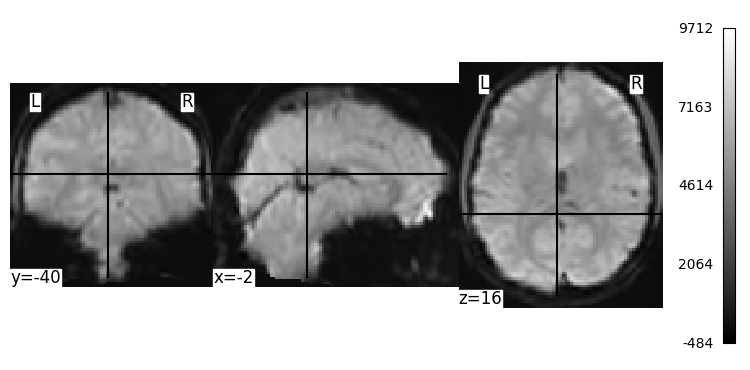

In [6]:
plot_img(mean, cbar_tick_format='%i')

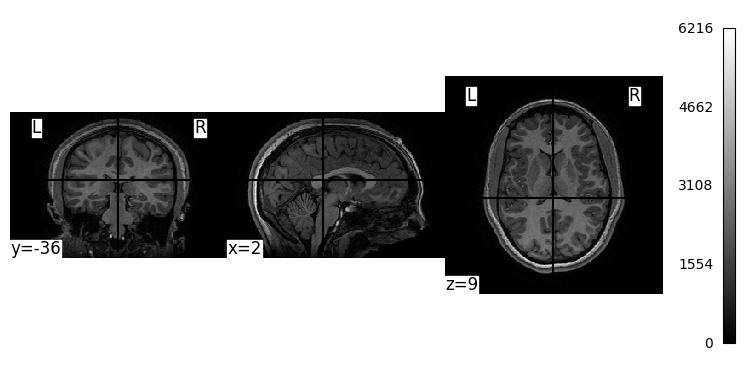

In [7]:
plot_img(anat, cbar_tick_format='%i')

In [8]:
run1_events_table = pd.read_table(run1_events)
run1_events_table

,onset,duration,trial_type,response_time
0,9.709,0.5,neutral,0.496
1,12.457,0.5,congruent,0.637
2,14.705,0.5,congruent,0.682
3,17.236,0.5,congruent,0.416
4,22.115,0.5,congruent,0.619
...,...,...,...,...
115,387.544,0.5,congruent,0.646
116,392.623,0.5,incongruent,0.528
117,397.652,0.5,incongruent,0.558
118,405.246,0.5,neutral,0.612


In [9]:
run2_events_table = pd.read_table(run2_events)
run2_events_table

,onset,duration,trial_type,response_time
0,9.720,0.5,neutral,0.526
1,14.965,0.5,incongruent,0.483
2,17.663,0.5,neutral,0.570
3,19.961,0.5,incongruent,0.471
4,22.209,0.5,neutral,0.561
...,...,...,...,...
115,392.167,0.5,incongruent,0.510
116,394.799,0.5,congruent,0.486
117,397.280,0.5,incongruent,0.458
118,402.326,0.5,congruent,0.423


In [10]:
run1_events_table.trial_type.value_counts()

trial_type
neutral        40
incongruent    38
congruent      37
error           5
Name: count, dtype: int64

In [11]:
run2_events_table.trial_type.value_counts()

trial_type
congruent      40
neutral        39
incongruent    37
error           4
Name: count, dtype: int64

In [12]:
run1_events_table.drop(columns=['response_time'], inplace=True)
run2_events_table.drop(columns=['response_time'], inplace=True)

In [13]:
run1_confounds_table = pd.read_table(run1_confounds, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
run1_confounds_table

,tx,ty,tz,rx,ry,rz
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.002512,-0.011666,-0.059746,0.000036,-0.000072,-0.000185
2,0.030545,-0.019003,-0.059758,0.000965,0.000236,0.000114
3,0.036071,-0.025118,-0.013280,0.000629,0.000763,0.000194
4,-0.010563,-0.018745,-0.101386,0.001915,0.000600,-0.000138
...,...,...,...,...,...,...
179,0.384871,0.726545,0.290079,0.010334,0.006442,0.005302
180,0.419632,0.730228,0.371095,0.010281,0.006749,0.005004
181,0.414883,1.181849,0.900111,-0.008052,0.007375,0.005747
182,0.368749,1.051799,0.679092,-0.002385,0.009065,0.005714


In [14]:
run2_confounds_table = pd.read_table(run2_confounds, header=None, names=['tx', 'ty', 'tz', 'rx', 'ry', 'rz'], sep='\\s+')
run2_confounds_table

,tx,ty,tz,rx,ry,rz
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,-0.042659,-0.026953,-0.075897,-0.000394,-0.001014,-0.000599
2,-0.081596,0.023870,-0.075238,-0.000313,-0.002442,-0.000514
3,-0.045863,0.041233,0.002642,-0.003397,-0.003127,0.000529
4,-0.011519,0.062620,-0.020303,-0.002659,-0.002204,0.000969
...,...,...,...,...,...,...
179,0.205423,0.776137,0.956626,0.010765,0.003436,0.003660
180,0.254920,0.818970,1.081816,0.007768,0.003451,0.005465
181,0.237705,0.766637,0.949059,0.011386,0.002492,0.005067
182,0.266125,0.979775,1.471644,-0.001660,0.002671,0.007285


In [15]:
run1_fmri = load_img(run1)
run2_fmri = load_img(run2)
rest_fmri = load_img(rest)

In [16]:
run1_fmri.shape, run2_fmri.shape, rest_fmri.shape

((79, 95, 79, 184), (79, 95, 79, 184), (79, 95, 79, 180))

In [17]:
mean_fmri = load_img(mean)
anat_mri = load_img(anat)
mean_fmri.shape, anat_mri.shape

((79, 95, 79), (256, 256, 124))

In [18]:
fl_glm = FirstLevelModel(
    t_r = 2.3,
    slice_time_ref = 0.0,  # first-slice was reference in slice-timing correction
    hrf_model = 'spm',
    drift_model = 'cosine',
    smoothing_fwhm = 6,
    high_pass = 0.01, 
    standardize = True,
    n_jobs = -1,
    verbose = 1
)

In [19]:
fl_glm.fit([run1_fmri, run2_fmri], events=[run1_events_table, run2_events_table], confounds=[run1_confounds_table, run2_confounds_table])

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001ADF63294C0>

[FirstLevelModel.fit] Computing mask

[FirstLevelModel.fit] Resamping mask

[FirstLevelModel.fit] Finished fit

[FirstLevelModel.fit] Computing run 1 out of 2 runs (go take a coffee, a big one).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001ADF63294C0>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 5 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 13 seconds.

[FirstLevelModel.fit] Computing run 2 out of 2 runs (19 seconds remaining).

[FirstLevelModel.fit] Performing mask computation.

[FirstLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x000001AD80060920>

[FirstLevelModel.fit] Smoothing images

[FirstLevelModel.fit] Extracting region signals

[FirstLevelModel.fit] Cleaning extracted signals

[FirstLevelModel.fit] Masking took 5 seconds.

[FirstLevelModel.fit] Performing GLM computation.

[FirstLevelModel.fit] GLM took 6 seconds.

[FirstLevelModel.fit] Computation of 2 runs done in 30 seconds.

,t_r,2.3
,slice_time_ref,0.0
,hrf_model,'spm'
,drift_model,'cosine'
,high_pass,0.01
,drift_order,1
,fir_delays,None
,min_onset,-24
,mask_img,None
,target_affine,None
,target_shape,None


In [20]:
len(fl_glm.design_matrices_)

2

In [21]:
run1_design_matrix, run2_design_matrix = fl_glm.design_matrices_

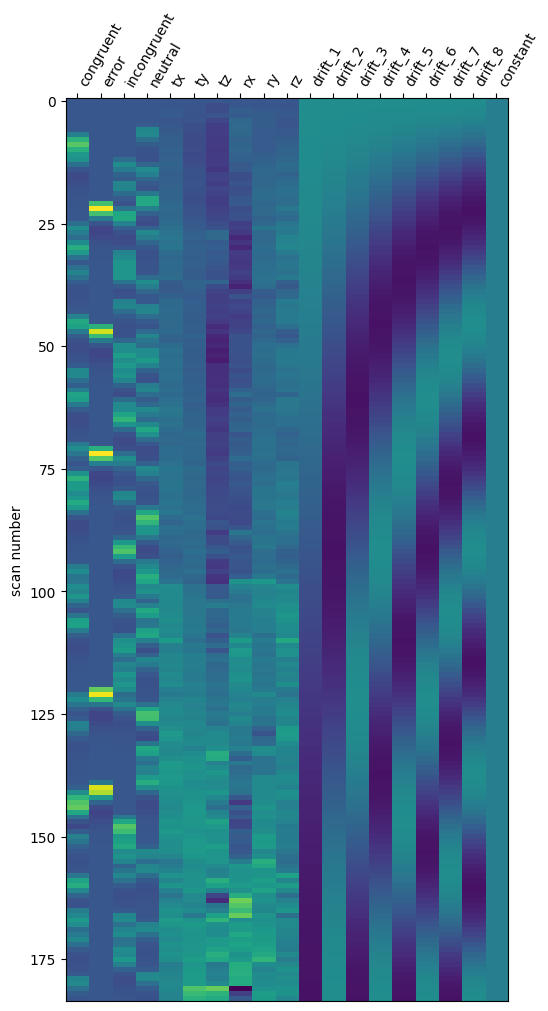

In [22]:
plot_design_matrix(run1_design_matrix)
show()

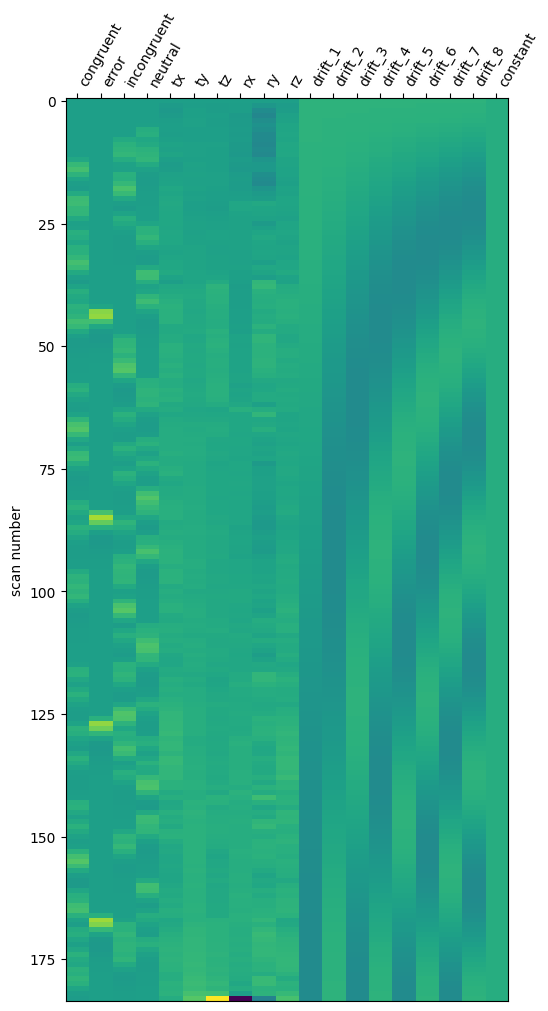

In [23]:
plot_design_matrix(run2_design_matrix)
show()

In [24]:
run1_events_table.trial_type.unique()

array(['neutral', 'congruent', 'incongruent', 'error'], dtype=object)

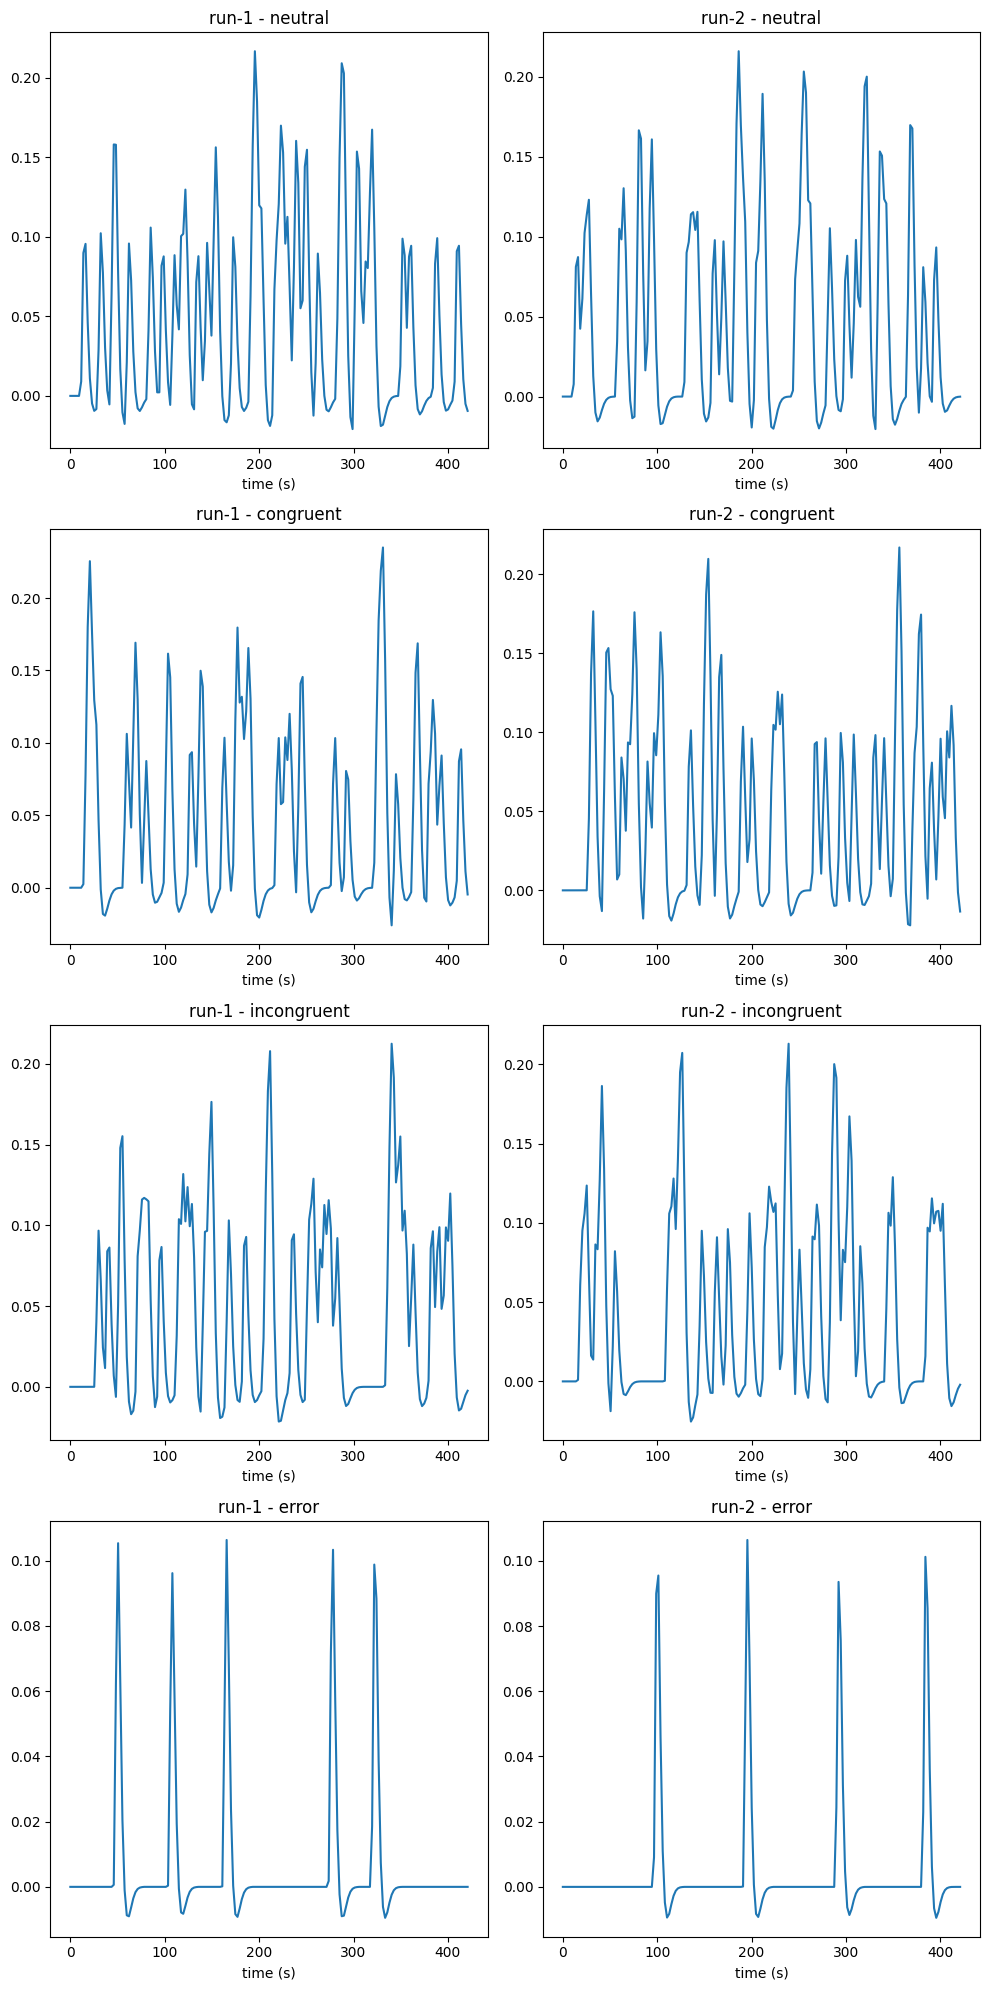

In [25]:
fig, axes = plt.subplots(4,2, figsize=(10,20))
axes = axes.flatten()

index = 0
run = ['run-1', 'run-2']

for effect in run1_events_table.trial_type.unique():
    for c, mat in enumerate(fl_glm.design_matrices_):
        axes[index].plot(mat[effect])
        axes[index].set_title(f"{run[c]} - {effect}")
        axes[index].set_xlabel('time (s)')
        index += 1
plt.tight_layout()
plt.show()

In [26]:
run1_design_matrix.shape

(184, 19)

In [27]:
run1_design_matrix.columns

Index(['congruent', 'error', 'incongruent', 'neutral', 'tx', 'ty', 'tz', 'rx',
       'ry', 'rz', 'drift_1', 'drift_2', 'drift_3', 'drift_4', 'drift_5',
       'drift_6', 'drift_7', 'drift_8', 'constant'],
      dtype='object')

In [28]:
contrasts = {
    "congruent_effect": "congruent",
    "incongruent_effect": "incongruent",
    "neutral_effect": "neutral",
    "incongruent_vs_congruent": "incongruent - congruent",
    "incongruent_vs_neutral": "incongruent - neutral",
    "neutral_vs_congruent": "neutral - congruent",
    "task_vs_baseline": "(congruent + incongruent + neutral) / 3",
    "error_monitoring": "error - (congruent + incongruent + neutral) / 3"
}

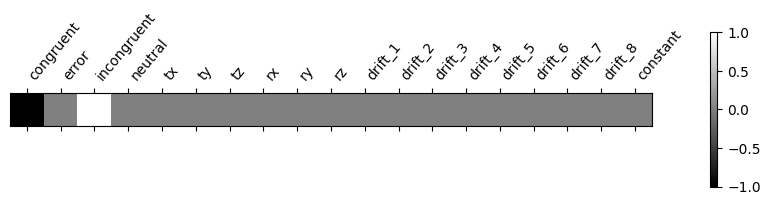

In [29]:
plot_contrast_matrix(contrasts["incongruent_vs_congruent"], design_matrix=run1_design_matrix)
show()

In [30]:
outputs_c1 = fl_glm.compute_contrast(
    contrast_def = contrasts["incongruent_vs_congruent"],
    stat_type = 't',
    output_type = 'all'
)

C:\Users\aleen\AppData\Local\Temp\ipykernel_21408\306309837.py:1: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  outputs_c1 = fl_glm.compute_contrast(


[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

In [31]:
type(outputs_c1)

dict

In [32]:
outputs_c1.items()

dict_items([('z_score', <nibabel.nifti1.Nifti1Image object at 0x000001ADF62FF350>), ('stat', <nibabel.nifti1.Nifti1Image object at 0x000001AD80062EA0>), ('p_value', <nibabel.nifti1.Nifti1Image object at 0x000001ADA8500EF0>), ('effect_size', <nibabel.nifti1.Nifti1Image object at 0x000001ADF61B7C80>), ('effect_variance', <nibabel.nifti1.Nifti1Image object at 0x000001ADA855AE10>)])

In [33]:
# outputs are averaged for both runs

In [34]:
z_map, t_map, p_map, contrast_map, effect_var_map = outputs_c1.values()

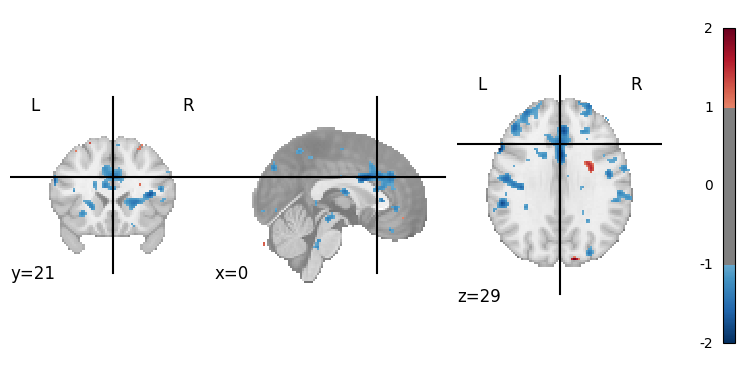

In [35]:
plot_stat_map(t_map, vmax=2, threshold=1)

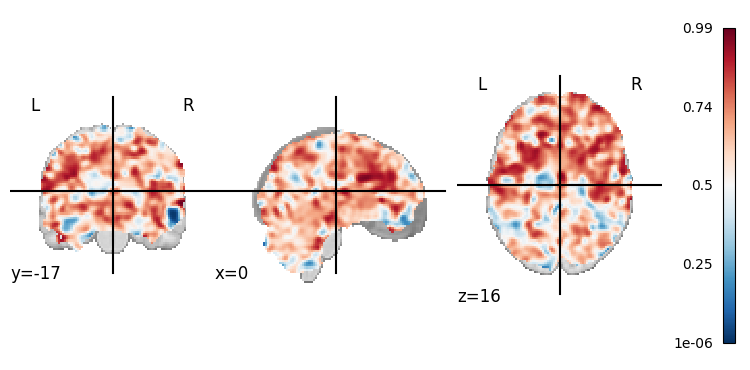

In [36]:
plot_stat_map(p_map)

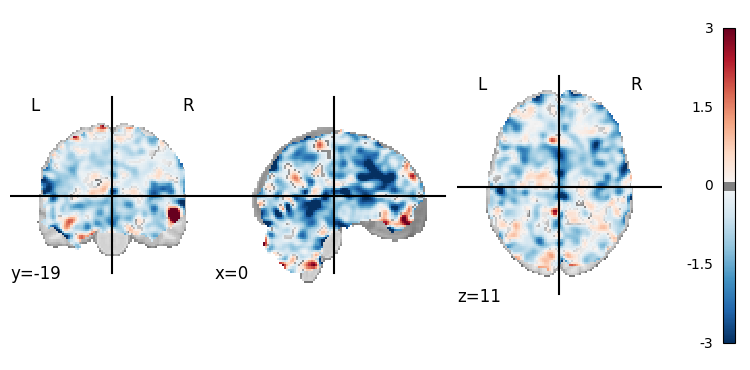

In [37]:
plot_stat_map(contrast_map, vmax=3, threshold=0.1)

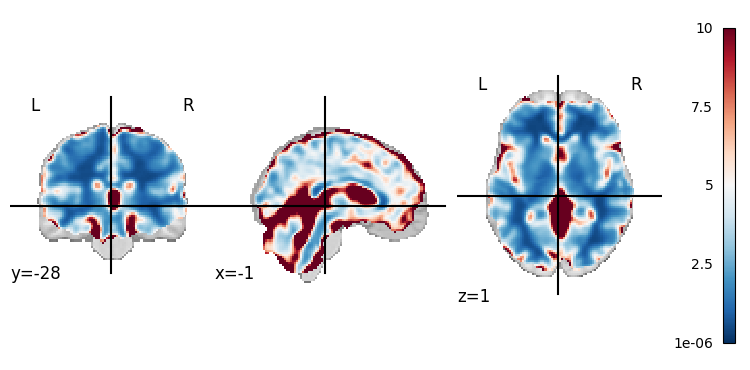

In [38]:
plot_stat_map(effect_var_map, vmax=10)

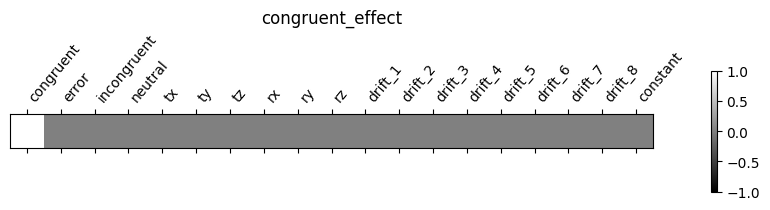

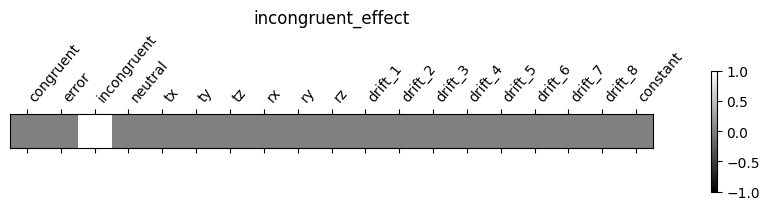

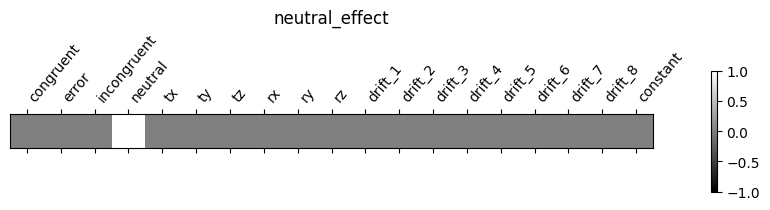

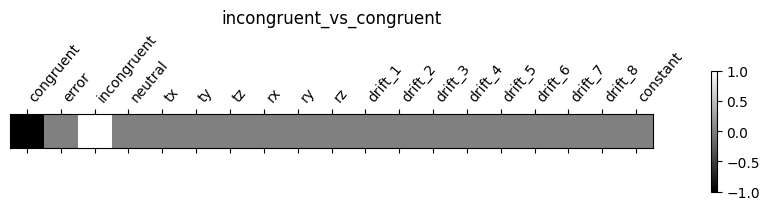

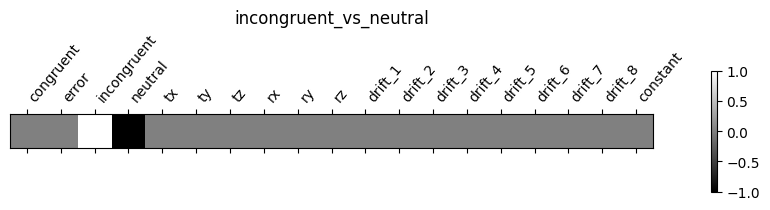

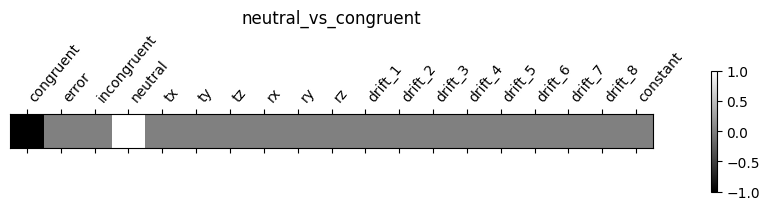

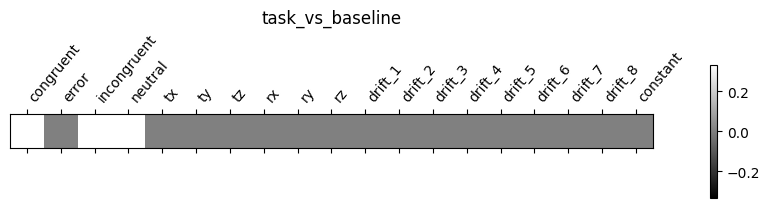

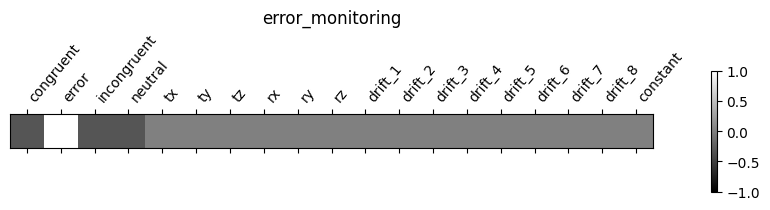

In [39]:
for contrast_name, contrast in contrasts.items():
    plot_contrast_matrix(contrast, design_matrix=run1_design_matrix)
    plt.title(contrast_name)
show()

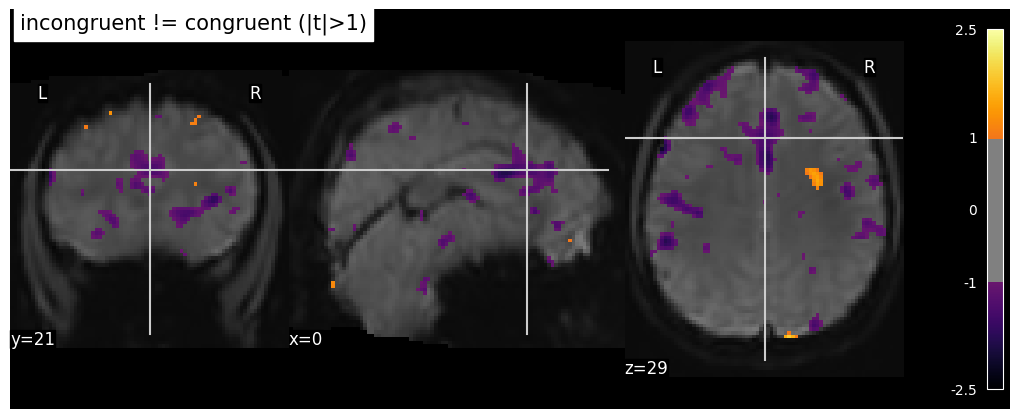

In [40]:
plotting_config = {
    'bg_img': mean_fmri,
    'cmap': 'inferno',
    'black_bg': True
}

plot_stat_map(
    t_map,
    threshold = 1,
    title = "incongruent != congruent (|t|>1)",
    figure = plt.figure(figsize=(10,4)),
    **plotting_config
)
show()

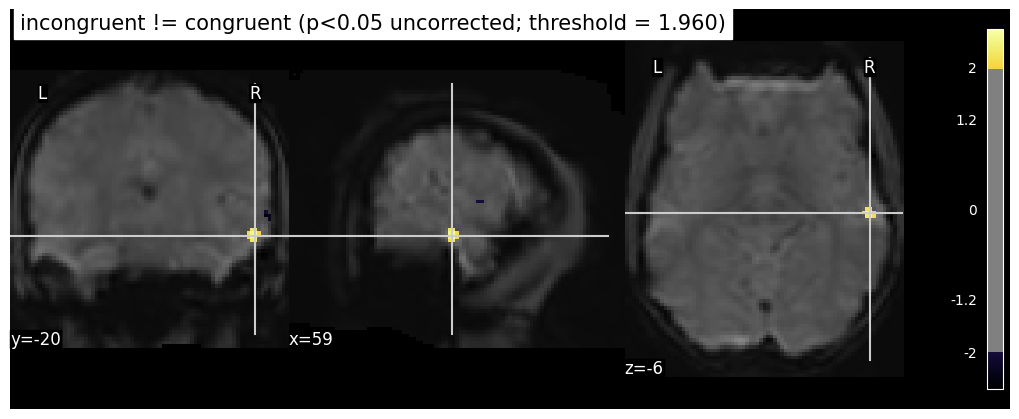

In [41]:
alpha = 0.05

clean_t_map, bon_threshold = threshold_stats_img(
    t_map, alpha=0.05, height_control='fpr'
)

plot_stat_map(
    clean_t_map, 
    threshold=bon_threshold,
    title=f"incongruent != congruent (p<{alpha} uncorrected; threshold = {bon_threshold:.3f})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

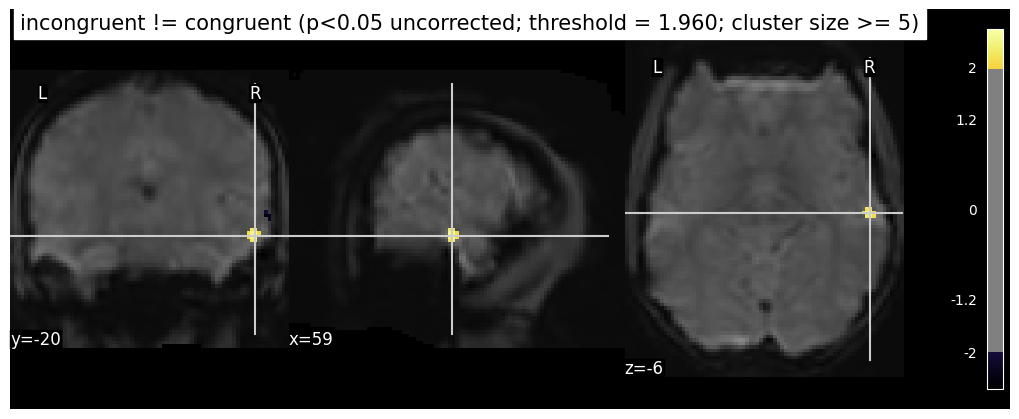

In [42]:
cluster = 5

clean_t_map, threshold = threshold_stats_img(
    t_map, alpha=alpha, height_control='fpr', cluster_threshold=cluster
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"incongruent != congruent (p<{alpha} uncorrected; threshold = {threshold:.3f}; cluster size >= {cluster})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

In [43]:
np.max(t_map.get_fdata()), np.min(t_map.get_fdata())

(2.3888751233030447, -2.4786379384735198)

In [44]:
np.max(z_map.get_fdata()), np.min(z_map.get_fdata())

(2.3768442457431203, -2.4653510496846835)

In [45]:
incong_vs_cong_clusters = get_clusters_table(
    t_map,
    stat_threshold = threshold,
    cluster_threshold = 10
)
incong_vs_cong_clusters

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,60.0,-20.0,-6.0,2.388875,192


In [46]:
outputs_taskVSbase = fl_glm.compute_contrast(
    contrast_def = contrasts["task_vs_baseline"],
    stat_type = 't',
    output_type = 'all'
)

C:\Users\aleen\AppData\Local\Temp\ipykernel_21408\3492023313.py:1: RuntimeWarning: The same contrast will be used for all 2 runs. If the design matrices are not the same for all runs, (for example with different column names or column order across runs) you should pass contrast as an expression using the name of the conditions as they appear in the design matrices.
  outputs_taskVSbase = fl_glm.compute_contrast(


[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

[FirstLevelModel.compute_contrast] Computing image from signals

In [47]:
outputs_taskVSbase.items()

dict_items([('z_score', <nibabel.nifti1.Nifti1Image object at 0x000001ADA8953F80>), ('stat', <nibabel.nifti1.Nifti1Image object at 0x000001ADF67A6FC0>), ('p_value', <nibabel.nifti1.Nifti1Image object at 0x000001ADF67A5D30>), ('effect_size', <nibabel.nifti1.Nifti1Image object at 0x000001ADF67A7C80>), ('effect_variance', <nibabel.nifti1.Nifti1Image object at 0x000001ADF67A75C0>)])

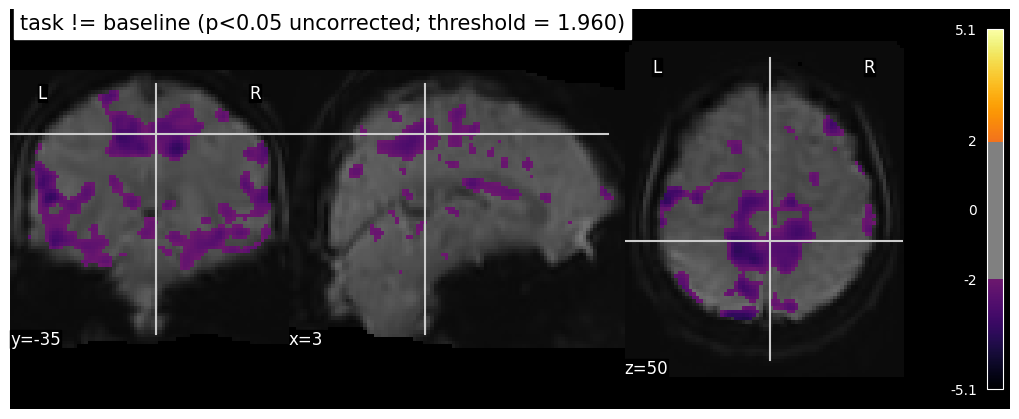

In [48]:
clean_t_map, threshold = threshold_stats_img(
    outputs_taskVSbase['stat'], alpha=alpha, height_control='fpr'
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"task != baseline (p<{alpha} uncorrected; threshold = {threshold:.3f})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

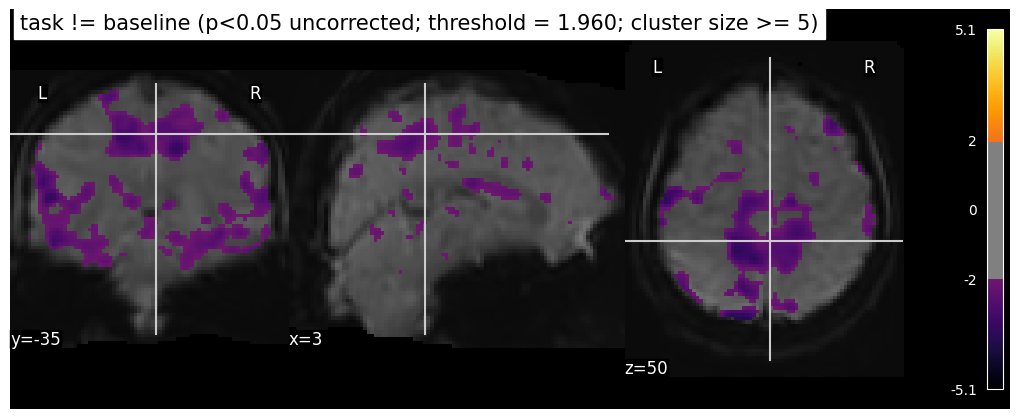

In [49]:
clean_t_map, threshold = threshold_stats_img(
    outputs_taskVSbase['stat'], alpha=alpha, 
    height_control='fpr', cluster_threshold=cluster
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"task != baseline (p<{alpha} uncorrected; threshold = {threshold:.3f}; cluster size >= {cluster})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

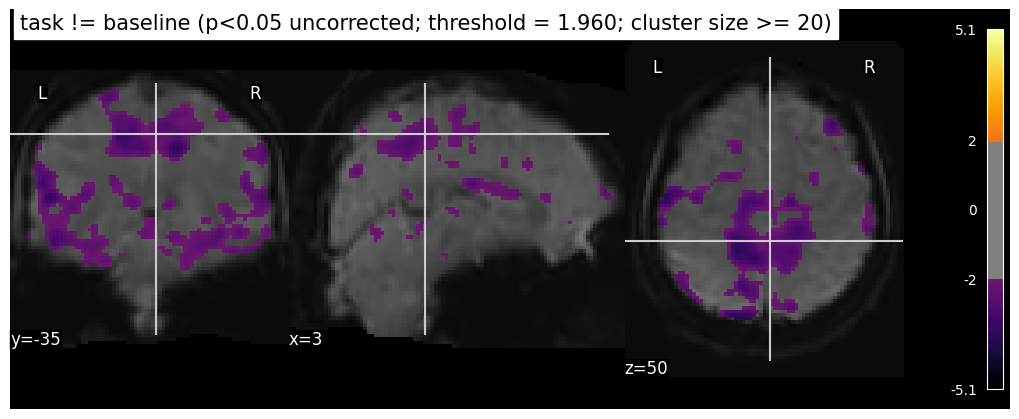

In [50]:
cluster = 20
clean_t_map, threshold = threshold_stats_img(
    outputs_taskVSbase['stat'], alpha=alpha, 
    height_control='fpr', cluster_threshold=cluster
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"task != baseline (p<{alpha} uncorrected; threshold = {threshold:.3f}; cluster size >= {cluster})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

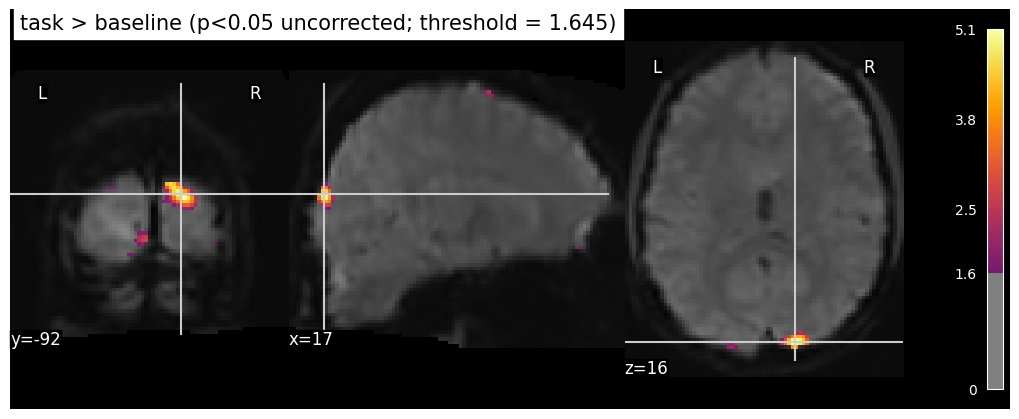

In [51]:
clean_t_map, threshold = threshold_stats_img(
    outputs_taskVSbase['stat'], alpha=alpha, height_control='fpr', two_sided=False
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"task > baseline (p<{alpha} uncorrected; threshold = {threshold:.3f})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

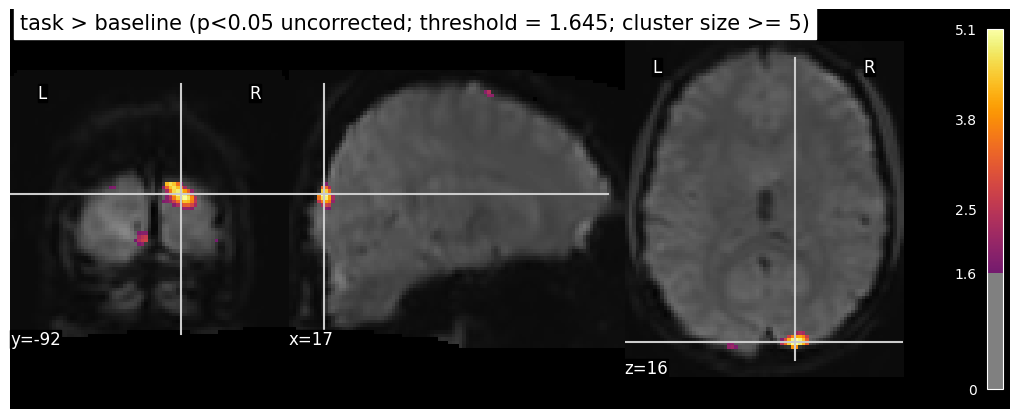

In [52]:
cluster = 5
clean_t_map, threshold = threshold_stats_img(
    outputs_taskVSbase['stat'], alpha=alpha, 
    height_control='fpr', two_sided=False, cluster_threshold=cluster
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"task > baseline (p<{alpha} uncorrected; threshold = {threshold:.3f}; cluster size >= {cluster})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

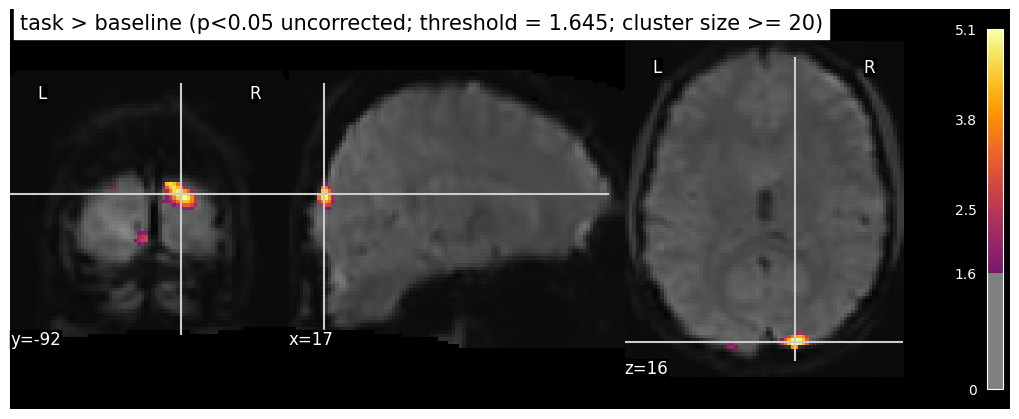

In [53]:
cluster = 20
clean_t_map, threshold = threshold_stats_img(
    outputs_taskVSbase['stat'], alpha=alpha, 
    height_control='fpr', two_sided=False, cluster_threshold=cluster
)

plot_stat_map(
    clean_t_map, 
    threshold=threshold,
    title=f"task > baseline (p<{alpha} uncorrected; threshold = {threshold:.3f}; cluster size >= {cluster})",
    figure=plt.figure(figsize=(10,4)),
    **plotting_config
)

show()

In [54]:
task_vs_baseline_clusters = get_clusters_table(
    outputs_taskVSbase['stat'],
    stat_threshold=threshold,
    cluster_threshold=cluster
)
task_vs_baseline_clusters

,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,18.0,-92.0,16.0,5.090360,1632
1,2,-32.0,-84.0,2.0,4.220198,1408
2,2a,-44.0,-86.0,6.0,4.090625,
3,3,30.0,-82.0,6.0,3.633007,712
4,4,-2.0,-88.0,-10.0,3.533544,616
5,5,-42.0,-74.0,-14.0,3.238151,696
6,5a,-32.0,-82.0,-12.0,2.690061,
7,6,52.0,-78.0,0.0,3.147911,200
8,7,-18.0,-96.0,12.0,3.104189,344
9,7a,-20.0,-94.0,20.0,1.939419,


In [55]:
roi_mask_img = threshold_img(outputs_taskVSbase['stat'], threshold=threshold, cluster_threshold=cluster, copy_header=True)
type(roi_mask_img)

nibabel.nifti1.Nifti1Image

In [56]:
# threshold_img?

In [57]:
# convert to 0/1 mask
roi_mask_data = (roi_mask_img.get_fdata() > 0).astype(int)
final_roi_mask = new_img_like(outputs_taskVSbase['stat'], roi_mask_data)

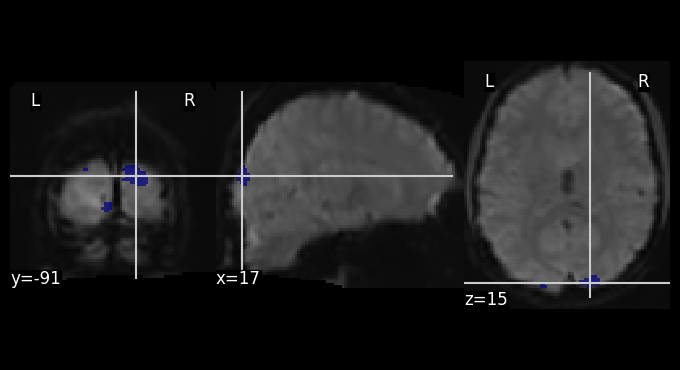

In [58]:
plot_roi(final_roi_mask, black_bg=True, bg_img=mean_fmri, colorbar=False)
show()

In [59]:
roi_mask_file = os.path.join(func_path, 'task_vs_baseline_ROI_mask.nii')
final_roi_mask.to_filename(roi_mask_file)

In [60]:
rest_roi_masker = NiftiMasker(mask_img=final_roi_mask, standardize=True, detrend=True)
masked_rsfmri = rest_roi_masker.fit_transform(load_img(rest))

In [61]:
type(masked_rsfmri)

numpy.ndarray

In [62]:
masked_rest = rest_roi_masker.inverse_transform(masked_rsfmri)

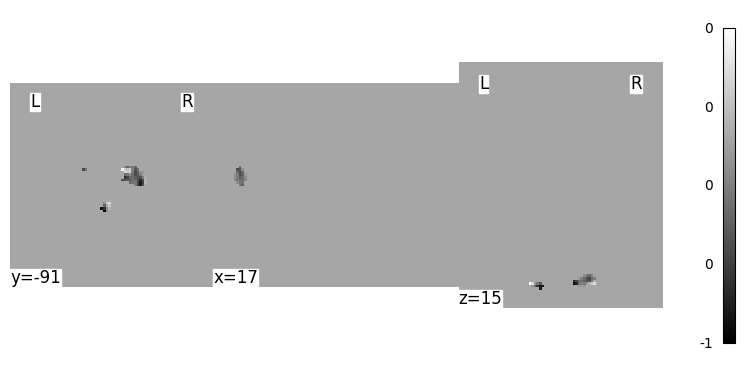

In [63]:
plot_img(index_img(masked_rest, 10), 
         cbar_tick_format='%i', 
         cut_coords=[17,-91,15], 
         draw_cross=False)
show()

In [64]:
rest_fmri.shape, masked_rest.shape

((79, 95, 79, 180), (79, 95, 79, 180))

In [65]:
outputs_taskVSbase['stat'].header.get_zooms()

(2.0, 2.0, 2.0)